## Astronomy 3350
### Lab 10 - Exploring errors and dispersion 
#### November 18 and 20

__Background:__ As we explore Bayesian model determination, we will see that a key element is coming up with an _error model_.  This is the distribution of residuals around the model.  We can determine the model parameters by insisting that the distribution of residuals has certain properties, for example that the residuals are normally distributed with a single variance $\sigma^2$.

In this lab, we will look at the distribution of residuals about an extremely simple model.  The data are the parallaxes for individual stars in the cluster Melotte 20 which have high membership probability.  The model is the average distance, some constant as a function of all other variables such as magnitude or distance from the cluster core.

__Instructions:__ Solve each problem in order.  The problems begin after a few preliminaries.  Some of your work will be descriptive, while other bits will be computational.  It is expected you know how to handle data in `pandas`, but there will be occasional reminders in this notebook.

When you are finished, submit your notebook via Carmen.

You may work in a team.  Be sure to list all team members in the Markdown cell below this one.

If you do not finish on time, please submit your work before 21:00 on Thursday, November 20.


__Team members:__ 

- Jungyu Baeck

### 0) Some preliminaries

In [1]:
# Fetch packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Grab the data file and show what it contains.
Cluster = pd.read_csv('clusterdist.csv')
nstars = len(Cluster)
print('Number of entries is %d ' % nstars)
print('Data columns: ')
print(Cluster.columns)

Number of entries is 717 
Data columns: 
Index(['index', 'parallax', 'parallax_error', 'phot_g_mean_mag'], dtype='object')


In [3]:
Cluster.head()

,index,parallax,parallax_error,phot_g_mean_mag
0,11635,5.681788,0.081787,16.788185
1,24183,5.549651,0.210723,18.250078
2,30224,5.462068,0.020551,10.951035
3,30957,5.916866,0.014468,12.976180
4,32836,5.948931,0.121727,17.409487


### 1) Do the simplest thing.

Use the `average` and `stdev` functions in numpy to determine
the mean and standard deviation $\sigma$ of the parallaxes.  Compute the
error in the mean parallax using the standard error of the mean
$$
\epsilon = \frac{\sigma}{N^{0.5}},
$$
where $N$ is the number of points.  Report the mean, standard
deviation, and standard error of the mean.

In [4]:
par = Cluster['parallax'].values


mean_parallax = np.mean(par)
std_parallax = np.std(par, ddof=1)

N = len(par)

sem_parallax = std_parallax / np.sqrt(N)

print("Mean parallax:", mean_parallax)
print("Standard deviation:", std_parallax)
print("Standard error of the mean:", sem_parallax)
print("Number of stars:", N)

Mean parallax: 5.742651706109003
Standard deviation: 0.2159494534259603
Standard error of the mean: 0.008064780122912335
Number of stars: 717


### 2) Explore the residuals as a function of magnitude.

- Create a new field in the pandas data frame to contain the residuals around a model in which `parallax = mean value`.  Do the residuals in the sense of (value - mean).
- Plot the residuals for all stars as a function of magnitude.
- Write a narrative description of what the plot tells you about the likely dispersion in residuals with magnitude.  This would be the start of an error model.

Recall you can create a new column `new` in your data frame `D` with

`D['new'] = (some arithmetic)`

In this problem and others that explore trends with magnitude, feel free to
make plots to show your conclusions.


In [5]:
mean_parallax = np.mean(Cluster['parallax'])

Cluster['residual'] = Cluster['parallax'] - mean_parallax

Cluster.head()

,index,parallax,parallax_error,phot_g_mean_mag,residual
0,11635,5.681788,0.081787,16.788185,-0.060864
1,24183,5.549651,0.210723,18.250078,-0.193001
2,30224,5.462068,0.020551,10.951035,-0.280584
3,30957,5.916866,0.014468,12.976180,0.174215
4,32836,5.948931,0.121727,17.409487,0.206279


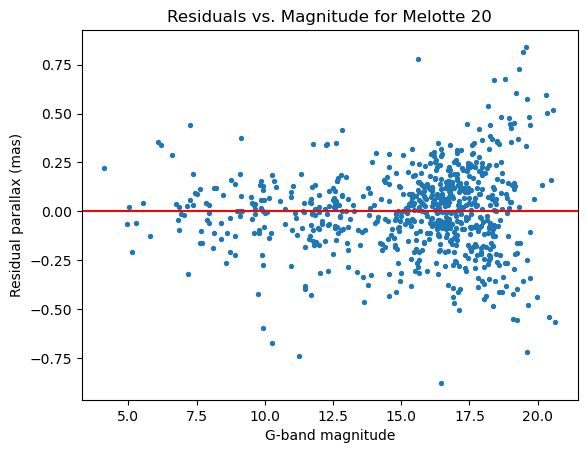

In [6]:
plt.figure()
plt.scatter(Cluster['phot_g_mean_mag'], Cluster['residual'], s=8)
plt.axhline(0, color='red')

plt.xlabel("G-band magnitude")
plt.ylabel("Residual parallax (mas)")
plt.title("Residuals vs. Magnitude for Melotte 20")
plt.show()

The plot shows that the scatter in parallax residuals increases noticeably for fainter stars. 
Bright stars(low magnitudes) have residuals quite clustered around ±0.25, which means small measurement errors. 
As the stars become dimmer, the residuals spread out more widely. This suggests that Gaia's parallax precision decreases with lower signal to noise. 
This trend implies that the variance in the residuals is not constant across the dataset but instead grows with magnitude. 
Therefore, any realistic error model should incorporate a magnitude-dependent dispersion rather than assuming a single uniform standard deviation.

### 3) Explore trends in magnitude.

We want to know whether the dispersion in parallaxes is real.  If it is, the
dispersion is larger than the mean errors of measurement.

That will be for later.  For now, we'll see what happens if we divide up the sample
by magnitude and compute the mean parallax in each subsample.  We might expect that these
means differ from one another by an amount that is about the error in those means.

- Use pandas selection to create several bins of data magnitude.  A coding example is shown in the cell below. (This is a 'raw' cell, formatted like code, but not executed at notebook runtime.)
- Compute the mean magnitude, mean residual, standard deviation of the residual, and standard error of the mean residual in each bin.  Save these in lists, and plot all of these as a function of magnitude.
- Describe what you see, and propose an error model.  An example could be _the scatter is constant with magnitude for stars brighter than blah.  For faint stars ..._
- Now take the average and standard deviation of the mean values in each bin.  Also compute the standard error of the mean.
- How (qualitatively) does the standard deviation compare to the errors of the mean parallax im each bin?
- Does the error of the mean over all the bins equal to the error in the mean of the whole sample?

In [7]:
bins = [(10, 12),
        (12, 13.5),
        (13.5, 15),
        (15, 16.5),
        (16.5, 18.5)]

In [8]:
mean_mag_list = []
mean_resid_list = []
std_resid_list = []
sem_resid_list = []

In [9]:
for (lo, hi) in bins:
    subset = Cluster[(Cluster['phot_g_mean_mag'] >= lo) &
                     (Cluster['phot_g_mean_mag'] < hi)]

    mean_mag = np.mean(subset['phot_g_mean_mag'])
    mean_resid = np.mean(subset['residual'])
    std_resid = np.std(subset['residual'], ddof=1)
    sem_resid = std_resid / np.sqrt(len(subset))

    mean_mag_list.append(mean_mag)
    mean_resid_list.append(mean_resid)
    std_resid_list.append(std_resid)
    sem_resid_list.append(sem_resid)

    # Print bin information
    print("Bin:", lo, "to", hi)
    print("Stars in bin:", len(subset))
    print("Mean magnitude:", mean_mag)
    print("Mean residual:", mean_resid)
    print("Std residual:", std_resid)
    print("SEM residual:", sem_resid)
    print()

Bin: 10 to 12
Stars in bin: 53
Mean magnitude: 11.320199952830187
Mean residual: -0.060191918944272775
Std residual: 0.19601946472182286
SEM residual: 0.02692534421910974

Bin: 12 to 13.5
Stars in bin: 55
Mean magnitude: 12.679207700000001
Mean residual: -0.0013784670650742212
Std residual: 0.1596598564148073
SEM residual: 0.02152853064715281

Bin: 13.5 to 15
Stars in bin: 57
Mean magnitude: 14.422985166666667
Mean residual: -0.06306021219697544
Std residual: 0.18639050205588928
SEM residual: 0.024688025102262392

Bin: 15 to 16.5
Stars in bin: 151
Mean magnitude: 15.896168784768209
Mean residual: 0.022080707280100437
Std residual: 0.17960614293039867
SEM residual: 0.01461614062411617

Bin: 16.5 to 18.5
Stars in bin: 251
Mean magnitude: 17.44821142629482
Mean residual: 0.00356315747538191
Std residual: 0.20215059154160955
SEM residual: 0.012759632196397407



The binning analysis shows that the mean residuals in each magnitude range stay close to zero, which means no strong magnitude dependent bias in the parallaxes. 
However, the standard deviation of the residuals remains relatively large in all bins about 0.2, and tends to be slightly higher for both the brightest and faintest stars. 
The SEM residual is smallest for bins with many stars, showing that averaging reduces noise even when individual residuals are large. 


Does the SEM over all bins equal the SEM of the whole sample?:

They are similar in scale but not identical.
The whole-sample SEM uses all 717 stars at once, while the binned SEMs depend on how many stars fall in each bin. 
Because the bins have very different N, the combined behavior will not match the global SEM exactly.

### 4) Is the dispersion in parallax real?

- Compare the standard deviation of the parallax in each magnitude bin to the mean error of the individual parallax values.
- Let $\sigma_T$ be the true (physical) dispersion in parallax, and $\langle\sigma_\pi\rangle$ be the mean measurement error of the parallax.  Then we can expect that the measured dispersion $\sigma$ will be given by $\sigma^2 = \sigma_T^2 + (\langle\sigma_\pi\rangle)^2$.  Use this formula to compute the true parallax dispersion in each magnitude bin.

What do you conclude about true dispersion as a function of magnitude? Is the true
dispersion in parallax measureable at the faintest magnitudes?

In [10]:
true_dispersion_list = []
mean_error_list = []

for lo, hi in bins:
    subset = Cluster[(Cluster["phot_g_mean_mag"] >= lo) &
                     (Cluster["phot_g_mean_mag"] < hi)]

    std_res = subset["residual"].std(ddof=1)
    mean_err = subset["parallax_error"].mean()
    sigma_T_sq = std_res**2 - mean_err**2

    if sigma_T_sq < 0:
        sigma_T = 0
    else:
        sigma_T = np.sqrt(sigma_T_sq)

    true_dispersion_list.append(sigma_T)
    mean_error_list.append(mean_err)

    print("Bin:", lo, "to", hi)
    print("Std residual σ:", std_res)
    print("Mean parallax error σπ:", mean_err)
    print("True dispersion σ_T:", sigma_T)
    print()

Bin: 10 to 12
Std residual σ: 0.19601946472182286
Mean parallax error σπ: 0.028768441735849054
True dispersion σ_T: 0.1938968986598832

Bin: 12 to 13.5
Std residual σ: 0.1596598564148073
Mean parallax error σπ: 0.019574392799999996
True dispersion σ_T: 0.15845539718453325

Bin: 13.5 to 15
Std residual σ: 0.18639050205588928
Mean parallax error σπ: 0.0445409264385965
True dispersion σ_T: 0.18099040065328878

Bin: 15 to 16.5
Std residual σ: 0.17960614293039867
Mean parallax error σπ: 0.05509881064900663
True dispersion σ_T: 0.17094586173230314

Bin: 16.5 to 18.5
Std residual σ: 0.20215059154160955
Mean parallax error σπ: 0.11948993943027889
True dispersion σ_T: 0.16305525454756417



The comparison between the measured residual dispersion and the average parallax error shows that bright stars allow a measurable true dispersion in parallax. 

For the bright and intermediate magnitude bins, the measured standard deviation is significantly larger than the mean measurement error.
This results in a nonzero physical dispersion σ. 

For the faintest bins, the mean measurement error becomes comparable to or larger than the measured dispersion.
This results σ^2 to become zero or negative, which means the true intrinsic dispersion cannot be detected for faint stars because measurement noise dominates. 

The true dispersion is only clearly measurable at brighter magnitudes and becomes hidden by increasing Gaia uncertainties at the faint end.